Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

Read data

In [2]:
merged_data = pd.read_csv("../../data/processed/merged_clean.csv")

Subset data for subgroup: 
Per_Level_Label = ["B2.1", "B2.2", "C1"],
Prof_Use_Label = "Yes"

In [3]:
subgroup = merged_data[
    (merged_data["Per_Level_Label"].isin(["B2.1", "B2.2", "C1"])
    ) & (merged_data["Prof_Use_Label"] == "Yes")      
]

In [4]:
subgroup.shape

(198, 31)

Goal_Type

Chi-square test: if Goal_Type had no relationship with Response_Full, what frequencies would we expect by chance?

Observed frequencies

In [5]:
goal_response = pd.crosstab(
    subgroup["Goal_Type"],
    subgroup["Response_Full"]
)

goal_response

Response_Full,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,25,16,24
goal_non_frequent,37,10,19
no_goal,34,12,18


Chi-square: Goal_type alone does not strongly organise responses (p-value: 0.2996)

In [6]:
chi2, p, dof, expected = chi2_contingency(goal_response)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 4.881818294163597
p-value: 0.2996400303327699
Degrees of freedom: 4


Cramér's V test: how strong does the structure appear to be?

Cramér's V: 0.1118 = small. Goal_Type by itself is not carrying the system.

In [7]:
n = goal_response.sum().sum()

k = min(goal_response.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.11188155703934266


Residuals: cells that contribute the most to chi-square association.

In [8]:
table = Table(goal_response)

In [9]:
residuals = table.standardized_resids

print(residuals)

Response_Full      L1_transfer  L2_other   correct
Goal_Type                                         
goal_frequent        -2.127004  1.278382  1.201372
goal_non_frequent     1.364540 -1.093309 -0.537326
no_goal               0.760282 -0.181651 -0.664616


goal_frequent conditions slightly stabilize restructuring and reduce L1_transfer pressure whereas non-frequent goals trend toward more L1_transfer and fewer correct responses. 

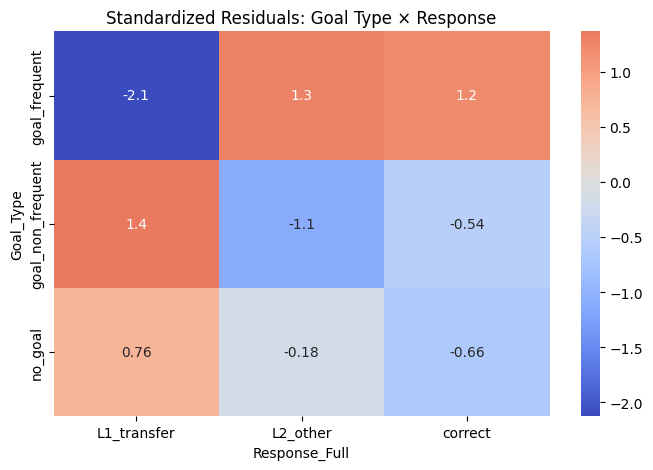

In [10]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Goal Type × Response")
plt.show()

Agent

Chi-square test: if Agent had no relationship with Response_Full, what frequencies would we expect by chance?

Observed frequencies

Observed frequencies

In [11]:
agent_response = pd.crosstab(
    subgroup["Agent"],
    subgroup["Response_Full"]
)

agent_response

Response_Full,L1_transfer,L2_other,correct
Agent,,,
0,57,31,35
1,39,7,26


Chi-square: response distributions differ by Agent more than what is expected by chance alone (p_value:0.0301) 

In [12]:
chi2, p, dof, expected = chi2_contingency(agent_response)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 7.00120075325133
p-value: 0.030179259060421543
Degrees of freedom: 2


Cramér's V: association exists but the overall magnitude is modest.

In [13]:
n = agent_response.sum().sum()

k = min(agent_response.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.18948243614229018


Residuals

In [14]:
table = Table(agent_response)

In [15]:
residuals = table.standardized_resids

print(residuals)

Response_Full  L1_transfer  L2_other   correct
Agent                                         
0                 -1.05482   2.63387 -1.112784
1                  1.05482  -2.63387  1.112784


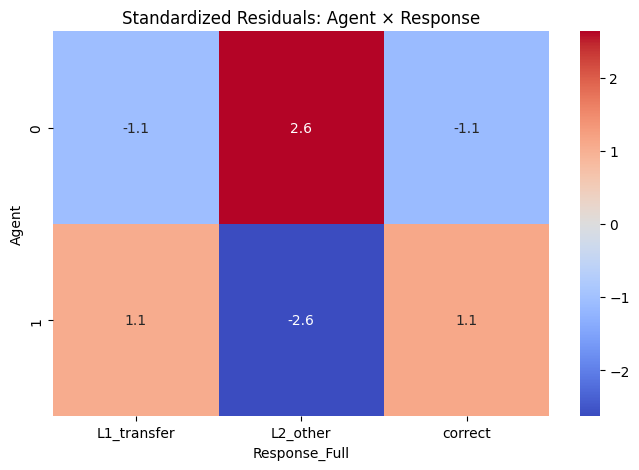

In [16]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Agent × Response")
plt.show()

Focus

Chi-square test: if Focus had no relationship with Response_Full, what frequencies would we expect by chance?

Observed frequencies

In [17]:
focus_response = pd.crosstab(
    subgroup["Focus"],
    subgroup["Response_Full"]
)

focus_response

Response_Full,L1_transfer,L2_other,correct
Focus,,,
I,53,24,40
They,43,14,21


Chi-square: response distributions do not differ by Focus more than what is expected by chance alone (p_value:0.3933) 

In [18]:
chi2, p, dof, expected = chi2_contingency(focus_response)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 1.8659150009586807
p-value: 0.39338854142719987
Degrees of freedom: 2


Cramér's V: the association is very moderate (Cramér's V: 0.0978). Focus on its own is not enough to create strong polarization.

In [19]:
n = focus_response.sum().sum()

k = min(focus_response.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.09782021711645902


Residuals

In [20]:
table = Table(focus_response)

In [21]:
residuals = table.standardized_resids

print(residuals)

Response_Full  L1_transfer  L2_other   correct
Focus                                         
I                -1.344981  0.442845  1.071947
They              1.344981 -0.442845 -1.071947


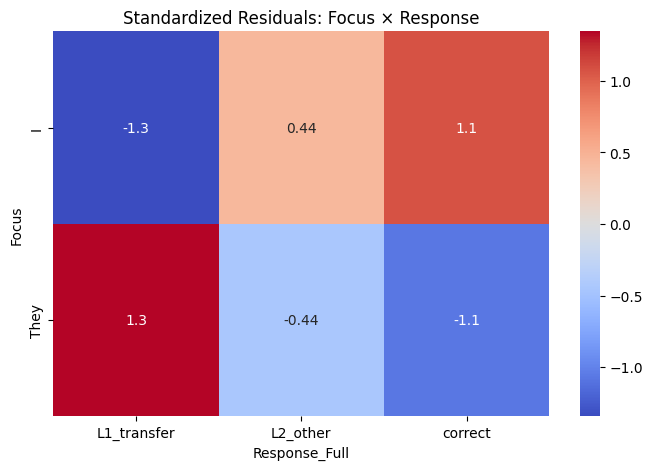

In [22]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Focus × Response")
plt.show()

Goal_Type X Agent

Chi-square test: if Goal_Type X Agent had no relationship with Response_Full, what frequencies would we expect by chance? 

Observed Frequencies

In [23]:
goal_agent_response = pd.crosstab(
    [subgroup["Goal_Type"], subgroup["Agent"]],
    subgroup["Response_Full"]
)

goal_agent_response

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Agent                                
goal_frequent     0               13        14       14
                  1               12         2       10
goal_non_frequent 0               21         9       12
                  1               16         1        7
no_goal           0               23         8        9
                  1               11         4        9

Chi-square: highest chi-square value so far but high p-value suggest that associations exist though they are distributed(p-value: 0.0957)

In [24]:
chi2, p, dof, expected = chi2_contingency(goal_agent_response)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 16.138577917830364
p-value: 0.0957335712459809
Degrees of freedom: 10


Expected counts

In [31]:
expected_df = pd.DataFrame(
    expected,
    index= goal_agent_response.index,
    columns=goal_agent_response.columns
)

display(expected_df.round(2))

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Agent                                
goal_frequent     0            20.18      7.99    12.83
                  1            11.82      4.68     7.51
goal_non_frequent 0            20.68      8.18    13.14
                  1            11.82      4.68     7.51
no_goal           0            19.69      7.79    12.51
                  1            11.82      4.68     7.51

In [32]:
print(
    f"Cells with expected counts < 5: "
    f"{(expected_df < 5).sum().sum()}"
)

Cells with expected counts < 5: 3


In [33]:
expected_df.round(2)

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Agent                                
goal_frequent     0            20.18      7.99    12.83
                  1            11.82      4.68     7.51
goal_non_frequent 0            20.68      8.18    13.14
                  1            11.82      4.68     7.51
no_goal           0            19.69      7.79    12.51
                  1            11.82      4.68     7.51

In [34]:
goal_agent_response

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Agent                                
goal_frequent     0               13        14       14
                  1               12         2       10
goal_non_frequent 0               21         9       12
                  1               16         1        7
no_goal           0               23         8        9
                  1               11         4        9

Cramér's V: the association is stronger than any of the variable of its own but still moderate (Cramér's V: 0.2034).

In [25]:
n = goal_agent_response.sum().sum()

k = min(goal_agent_response.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.20342312803631218


Residuals

In [26]:
table = Table(goal_agent_response)

In [27]:
residuals = table.standardized_resids

print(residuals)

Response_Full            L1_transfer  L2_other   correct
Goal_Type         Agent                                 
goal_frequent     0        -2.525515  2.666558  0.445126
                  1         0.080494 -1.473135  1.171744
goal_non_frequent 0         0.112573  0.358594 -0.427743
                  1         1.824528 -2.023444 -0.238689
no_goal           0         1.173351  0.091842 -1.343676
                  1        -0.355515 -0.372517  0.701600


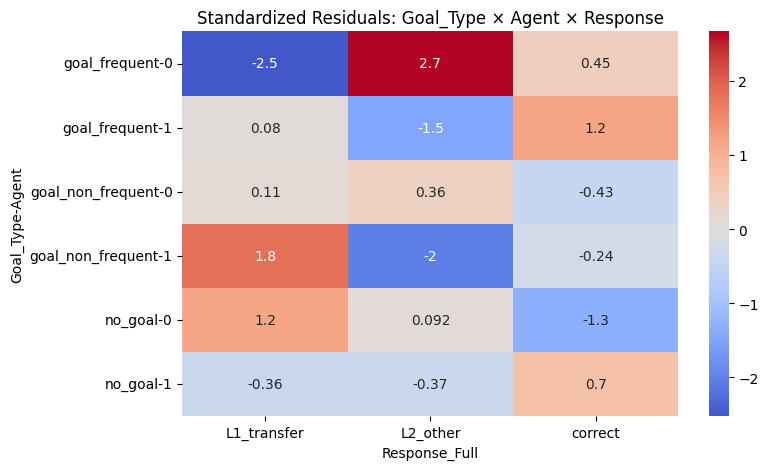

In [28]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals, 
    annot= True,
    cmap= "coolwarm",
    center = 0
)

plt.title("Standardized Residuals: Goal_Type × Agent × Response")
plt.show()